# Task 3: Random Walks

## Required Imports

In [1]:
from collections import defaultdict
import itertools

import numpy as np
import pandas as pd
import networkx as nx
import itertools

import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
drive.mount("/content/drive")

SEED = 42

Mounted at /content/drive


## Load Dataset and Construct MultiDiGraph with Features

In [2]:
df_links = pd.read_csv("/content/drive/My Drive/ORF387_Project/heaberlin_dedeo_norm_network/links.csv")
print(df_links)

       Source  Target
0           0     117
1           0     491
2           0     603
3           0     773
4           0    1020
...       ...     ...
17230    1975    1038
17231    1975    1254
17232    1975    1381
17233    1975    1719
17234    1975    1765

[17235 rows x 2 columns]


In [3]:
df_nodes = pd.read_csv("/content/drive/My Drive/ORF387_Project/heaberlin_dedeo_norm_network/nodes.csv", sep="\t")
print(df_nodes.head(1))

   Page ID                        Name            Creation Date   Type  \
0        0  In_popular_culture_content  2007-02-12 18:56:47 UTC  Essay   

   Louvain Community  Final In Degree  EC Estimate  \
0                  1                0     0.000163   

   Fraction of total pageviews (July 2015)  Number of Edits  Unique Editors  \
0                                 0.000205              399             171   

   Number of Talk Page Edits  Unique Talk Page Editors  Page Size  
0                        267                       267       1560  


In [4]:
df_topics = pd.read_csv("/content/drive/My Drive/ORF387_Project/heaberlin_dedeo_norm_network/topics.csv", sep="\t")
print(df_topics.head(1))

   Page ID  Number of Words       Topic 1   Topic 2       Topic 3   Topic 4  \
0        0            959.0  1.710234e-19  0.076057  2.305177e-19  0.653648   

        Topic 5   Topic 6       Topic 7   Topic 8  ...      Topic 11  \
0  1.143827e-19  0.034452  1.117835e-19  0.235844  ...  1.289104e-19   

       Topic 12      Topic 13      Topic 14      Topic 15      Topic 16  \
0  1.473083e-19  1.676075e-19  1.812079e-19  1.077796e-19  1.215833e-19   

       Topic 17      Topic 18      Topic 19      Topic 20  
0  9.847681e-20  1.560968e-19  2.410273e-19  1.947174e-19  

[1 rows x 22 columns]


In [5]:
df_all_node_features = df_nodes.merge(df_topics, on="Page ID", how="left")
print(df_all_node_features.columns)

Index(['Page ID', 'Name', 'Creation Date', 'Type', 'Louvain Community',
       'Final In Degree', 'EC Estimate',
       'Fraction of total pageviews (July 2015)', 'Number of Edits',
       'Unique Editors', 'Number of Talk Page Edits',
       'Unique Talk Page Editors', 'Page Size', 'Number of Words', 'Topic 1',
       'Topic 2', 'Topic 3', 'Topic 4', 'Topic 5', 'Topic 6', 'Topic 7',
       'Topic 8', 'Topic 9', 'Topic 10', 'Topic 11', 'Topic 12', 'Topic 13',
       'Topic 14', 'Topic 15', 'Topic 16', 'Topic 17', 'Topic 18', 'Topic 19',
       'Topic 20'],
      dtype='object')


In [6]:
# Consulted official NetworkX documentation at:
# https://networkx.org/documentation/stable/reference/generated/networkx.convert_matrix.from_pandas_edgelist.html
# https://networkx.org/documentation/stable/reference/classes/multidigraph.html

G = nx.from_pandas_edgelist(df_links, source="Source", target="Target", create_using=nx.MultiDiGraph)
G.add_nodes_from((n, dict(d)) for n, d in df_all_node_features.iterrows())
id_to_name = df_nodes.set_index("Page ID")["Name"].to_dict()
id_to_comm = df_nodes.set_index("Page ID")["Louvain Community"].to_dict()
print(G)
print(G.nodes[0])

MultiDiGraph with 1976 nodes and 17235 edges
{'Page ID': 0, 'Name': 'In_popular_culture_content', 'Creation Date': '2007-02-12 18:56:47 UTC', 'Type': 'Essay', 'Louvain Community': 1, 'Final In Degree': 0, 'EC Estimate': 0.0001626162778894, 'Fraction of total pageviews (July 2015)': 0.0002048444547773, 'Number of Edits': 399, 'Unique Editors': 171, 'Number of Talk Page Edits': 267, 'Unique Talk Page Editors': 267, 'Page Size': 1560, 'Number of Words': 959.0000000000008, 'Topic 1': 1.7102336566440234e-19, 'Topic 2': 0.0760565545515698, 'Topic 3': 2.3051774762843663e-19, 'Topic 4': 0.6536475757107106, 'Topic 5': 1.1438267247712907e-19, 'Topic 6': 0.0344516308097106, 'Topic 7': 1.1178345700816128e-19, 'Topic 8': 0.2358442389280088, 'Topic 9': 1.7296337030998024e-19, 'Topic 10': 1.632536850442116e-19, 'Topic 11': 1.289104362176843e-19, 'Topic 12': 1.4730825295684649e-19, 'Topic 13': 1.6760750797243862e-19, 'Topic 14': 1.8120792587481965e-19, 'Topic 15': 1.0777963642246984e-19, 'Topic 16': 1

In [7]:
# Filter nodes by timestamp up to end of 2007
df_nodes_by_timestamp = pd.to_datetime(df_nodes.set_index("Page ID")["Creation Date"], utc=True)
cutoff_2007 = pd.Timestamp("2007-12-31", tz="UTC")
df_nodes_2007 = df_nodes_by_timestamp[df_nodes_by_timestamp <= cutoff_2007].index

# Filter edges by timestamp up to end of 2007
mask = df_links["Source"].isin(df_nodes_2007) & df_links["Target"].isin(df_nodes_2007)
df_links_2007 = df_links[mask]

# Create a subgraph from the nodes and edges which existed by the end of 2007
G_2007 = nx.from_pandas_edgelist(df_links_2007, source="Source", target="Target", create_using=nx.MultiDiGraph)
G_2007.add_nodes_from((n, dict(d)) for n, d in df_all_node_features[df_all_node_features["Page ID"].isin(df_nodes_2007)].iterrows())
print(G_2007)

MultiDiGraph with 1005 nodes and 8623 edges


In [8]:
community_labels = {
    1: "Article Quality",
    2: "Collaboration",
    3: "Administrators",
    4: "Formatting Articles",
    5: "Content Policies",
    6: "Wiki-larping",
    7: "Page Templates",
    8: "Experts and Credentials",
    9: "Humor",
    10: "None",
    -1: "None"
}

## Perform Random Walks

* Note: Because our graph is directed, NetworkX's ```generate_random_paths()``` encounters an error with deadends. We fix this for deterministic transition random walks by adding self-loops to disconnected nodes (this ensures we don't alter existing paths)


In [9]:
def random_walk(G, num_walks, walk_length, alpha=1):
    walks = []

    if alpha == 1:
        g = G.copy()
        for node in g:
            if g.out_degree(node) == 0:
                g.add_edge(node, node)

        walks = list(nx.generate_random_paths(g, path_length=walk_length, sample_size=num_walks, seed=SEED))
    else:
        nodes = list(G.nodes())
        idx_to_node = {}
        node_to_idx = {}
        for idx, node in enumerate(list(G.nodes())):
            idx_to_node[idx] = node
            node_to_idx[node] = idx

        # PageRank teleportation, bias towards edge pairs with more edges (MultiDiGraph)
        T = nx.google_matrix(G, alpha=alpha, nodelist=list(G.nodes()))
        for _ in range(num_walks):
            walk = []
            current = idx_to_node[np.random.randint(len(nodes))]
            walk.append(current)

            for _ in range(walk_length):
                transitions = T[node_to_idx[current]]
                current = idx_to_node[int(np.random.choice(np.arange(len(nodes)), p=transitions))]
                walk.append(current)
            walks.append(walk)

    for i, walk in enumerate(walks):
        for j, node in enumerate(walk):
            walks[i][j] = (id_to_name[node], community_labels[id_to_comm[node]])

    return walks

## Random Walk Analysis

In [10]:
def compute_hitting_times(walks):
    hitting_times = defaultdict(list)

    # Loop through the walks and record every first time a node appears over all walks
    for walk in walks:
        encountered = set()
        for timestep, node in enumerate(walk):
            if node not in encountered:
                hitting_times[node].append(timestep)
                encountered.add(node)

    return {node: np.mean(times) for node, times in hitting_times.items()}

In [11]:
def fraction_of_learned_communities(walks):
    fractions = []

    for walk in walks:
        encountered = set()

        for _, community in walk:
            if community in community_labels.values() and community not in encountered and community != "None":
                encountered.add(community)

        fraction_encountered = len(encountered) / 9
        fractions.append(fraction_encountered)

    return fractions, np.mean(fractions)

In [12]:
def community_learning_curve(walk):
    encountered = set()
    curve = []

    for _, community in walk:
        if community in community_labels.values() and community not in encountered and community != "None":
            encountered.add(community)
        curve.append(len(encountered) / 9)

    return curve


def average_learning_curve(walks):
    curves = [community_learning_curve(w) for w in walks]

    # We take the average fraction learned at each timestep
    return np.mean(curves, axis=0)

#### 2001-2015

In [13]:
curves_by_alpha_10 = defaultdict(list)

walk_length = 10
for alpha in [1, 0.85, 0.5]:
    for random_trial in np.arange(5):
        print(f"Trial {random_trial}: Walk Length = {walk_length}, Alpha = {alpha}")
        seed = 42 + 100 * random_trial
        np.random.seed(seed)

        walks = random_walk(G, num_walks=1000, walk_length=walk_length, alpha=alpha)

        hitting_times = sorted(compute_hitting_times(walks).items(), key=lambda x:x[1])
        fastest_5 = hitting_times[:5]
        slowest_5 = hitting_times[-5:]

        fractions, avg_fraction = fraction_of_learned_communities(walks)
        max_fraction = max(fractions)
        min_fraction = min(fractions)

        fraction_per_step = average_learning_curve(walks)
        curves_by_alpha_10[alpha].append(fraction_per_step)

        print("Fastest 5 hitting times:", fastest_5)
        print("Slowest 5 hitting times:", slowest_5)
        print("Maximum fraction of learned norms in a walk:", max_fraction)
        print("Minimum fraction of learned norms in a walk:", min_fraction)
        print()
    print("____________________________________________________________")

Trial 0: Walk Length = 10, Alpha = 1
Fastest 5 hitting times: [(('The_GNG_and_notability_for_actors', 'Article Quality'), np.float64(0.0)), (('Notability_(media)', 'Article Quality'), np.float64(0.0)), (("Wikipedia_doesn't_use_Allwiki", 'None'), np.float64(0.0)), (('Sociology_of_Wikipedia_via_Rorty_and_Berger', 'None'), np.float64(0.0)), (('Notability_(Railway_lines_and_stations)', 'Article Quality'), np.float64(0.0))]
Slowest 5 hitting times: [(('Notability_(academic_journals)', 'Article Quality'), np.float64(10.0)), (('Discussing_cruft', 'Article Quality'), np.float64(10.0)), (('Secure_server', 'Administrators'), np.float64(10.0)), (('Naming_conventions_(Slovenian_vs_Slovene)', 'Formatting Articles'), np.float64(10.0)), (('Complete_diff_and_link_guide', 'Administrators'), np.float64(10.0))]
Maximum fraction of learned norms in a walk: 0.6666666666666666
Minimum fraction of learned norms in a walk: 0.0

Trial 1: Walk Length = 10, Alpha = 1
Fastest 5 hitting times: [(('The_GNG_and_nota

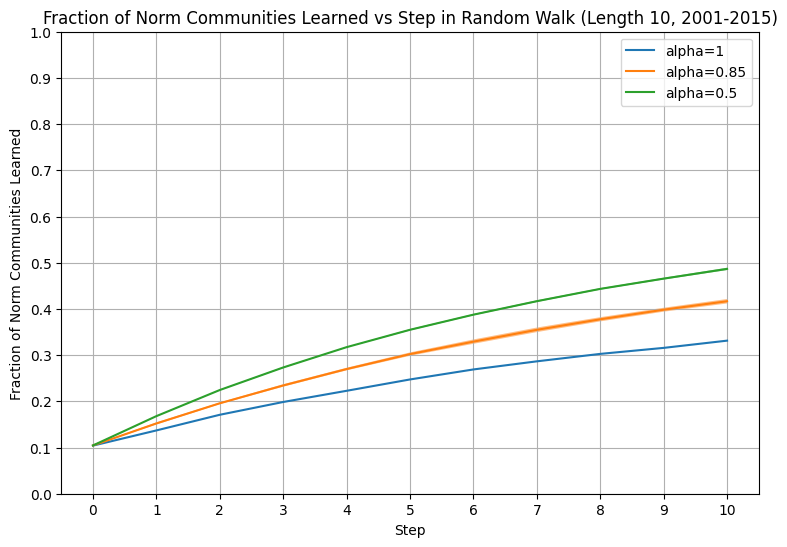

In [14]:
stats_by_alpha_10 = {}

for alpha, curves in curves_by_alpha_10.items():
    curves = np.array(curves)

    # Average across trials for each alpha
    mean_curve = np.mean(curves, axis=0)
    std_curve = np.std(curves, axis=0)

    stats_by_alpha_10[alpha] = (mean_curve, std_curve)

plt.figure(figsize=(9, 6))

for alpha, (mean_curve, std_curve) in stats_by_alpha_10.items():
    x = np.arange(len(mean_curve))

    plt.plot(x, mean_curve, label=f'alpha={alpha}')
    plt.fill_between(
        x,
        mean_curve - std_curve,
        mean_curve + std_curve,
        alpha=0.5
    )

plt.xlabel("Step")
plt.ylabel("Fraction of Norm Communities Learned")
plt.title("Fraction of Norm Communities Learned vs Step in Random Walk (Length 10, 2001-2015)")
plt.ylim(0, 1)
plt.yticks(np.arange(0, 1.1, 0.1))
plt.xticks(np.arange(0, 11, 1))
plt.legend()
plt.grid(True)

plt.show()

In [15]:
curves_by_alpha_100 = defaultdict(list)

walk_length = 100
for alpha in [1, 0.85, 0.5]:
    for random_trial in np.arange(5):
        print(f"Trial {random_trial}: Walk Length = {walk_length}, Alpha = {alpha}")
        seed = 42 + 100 * random_trial
        np.random.seed(seed)

        walks = random_walk(G, num_walks=1000, walk_length=walk_length, alpha=alpha)

        hitting_times = sorted(compute_hitting_times(walks).items(), key=lambda x:x[1])
        fastest_5 = hitting_times[:5]
        slowest_5 = hitting_times[-5:]

        fractions, avg_fraction = fraction_of_learned_communities(walks)
        max_fraction = max(fractions)
        min_fraction = min(fractions)

        fraction_per_step = average_learning_curve(walks)
        curves_by_alpha_100[alpha].append(fraction_per_step)

        print("Fastest 5 hitting times:", fastest_5)
        print("Slowest 5 hitting times:", slowest_5)
        print("Maximum fraction of learned norms in a walk:", max_fraction)
        print("Minimum fraction of learned norms in a walk:", min_fraction)
        print()
    print("____________________________________________________________")

Trial 0: Walk Length = 100, Alpha = 1
Fastest 5 hitting times: [(('Authority_control', 'Formatting Articles'), np.float64(0.0)), (('Short_horizontal_line', 'Formatting Articles'), np.float64(0.0)), (('Uphill_battles', 'Collaboration'), np.float64(0.0)), (('Coherence_and_cohesion', 'None'), np.float64(0.0)), (('Scavenger_hunt', 'None'), np.float64(0.0))]
Slowest 5 hitting times: [(('You_are_not_irreplaceable', 'Collaboration'), np.float64(90.0)), (('Notable_person_survival_kit', 'Article Quality'), np.float64(90.0)), (('Graphic_and_potentially_disturbing_images', 'Content Policies'), np.float64(90.0)), (('Simplest_diff_guide', 'Collaboration'), np.float64(92.0)), (('Wikipedia_does_not_need_you', 'Collaboration'), np.float64(95.0))]
Maximum fraction of learned norms in a walk: 0.8888888888888888
Minimum fraction of learned norms in a walk: 0.0

Trial 1: Walk Length = 100, Alpha = 1
Fastest 5 hitting times: [(('Authority_control', 'Formatting Articles'), np.float64(0.0)), (('Short_horizon

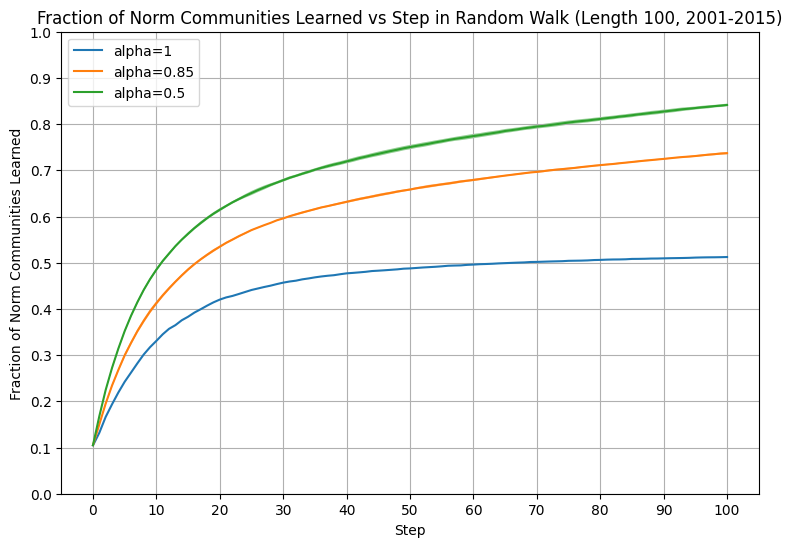

In [16]:
stats_by_alpha_100 = {}

for alpha, curves in curves_by_alpha_100.items():
    curves = np.array(curves)

    # Average across trials for each alpha
    mean_curve = np.mean(curves, axis=0)
    std_curve = np.std(curves, axis=0)

    stats_by_alpha_100[alpha] = (mean_curve, std_curve)

plt.figure(figsize=(9, 6))

for alpha, (mean_curve, std_curve) in stats_by_alpha_100.items():
    x = np.arange(len(mean_curve))

    plt.plot(x, mean_curve, label=f'alpha={alpha}')
    plt.fill_between(
        x,
        mean_curve - std_curve,
        mean_curve + std_curve,
        alpha=0.5
    )

plt.xlabel("Step")
plt.ylabel("Fraction of Norm Communities Learned")
plt.ylim(0, 1)
plt.yticks(np.arange(0, 1.1, 0.1))
plt.xticks(np.arange(0, 101, 10))
plt.title("Fraction of Norm Communities Learned vs Step in Random Walk (Length 100, 2001-2015)")
plt.legend()
plt.grid(True)

plt.show()

In [17]:
curves_by_alpha_1000 = defaultdict(list)

walk_length = 1000
for alpha in [1, 0.85, 0.5]:
    for random_trial in np.arange(5):
        print(f"Trial {random_trial}: Walk Length = {walk_length}, Alpha = {alpha}")
        seed = 42 + 100 * random_trial
        np.random.seed(seed)

        walks = random_walk(G, num_walks=1000, walk_length=walk_length, alpha=alpha)

        hitting_times = sorted(compute_hitting_times(walks).items(), key=lambda x:x[1])
        fastest_5 = hitting_times[:5]
        slowest_5 = hitting_times[-5:]

        fractions, avg_fraction = fraction_of_learned_communities(walks)
        max_fraction = max(fractions)
        min_fraction = min(fractions)

        fraction_per_step = average_learning_curve(walks)
        curves_by_alpha_1000[alpha].append(fraction_per_step)

        print("Fastest 5 hitting times:", fastest_5)
        print("Slowest 5 hitting times:", slowest_5)
        print("Maximum fraction of learned norms in a walk:", max_fraction)
        print("Minimum fraction of learned norms in a walk:", min_fraction)
        print()
    print("____________________________________________________________")

Trial 0: Walk Length = 1000, Alpha = 1
Fastest 5 hitting times: [(('College_and_university_article_guidelines', 'Article Quality'), np.float64(0.0)), (('Please_use_spellcheck', 'None'), np.float64(0.0)), (('Headless_Chickens', 'Collaboration'), np.float64(0.0)), (('Proposed_guideline_for_lists_of_people_by_ethnicity,_religion,_and_other_cultural_categorizations', 'Formatting Articles'), np.float64(0.0)), (('Notability_sub-pages', 'Article Quality'), np.float64(0.0))]
Slowest 5 hitting times: [(("Evaluating_how_interesting_an_integer's_mathematical_property_is", 'Article Quality'), np.float64(231.0)), (('Research_recruitment', 'Content Policies'), np.float64(233.0)), (('Proposed_blanking', 'Formatting Articles'), np.float64(246.0)), (('Leave_it_to_the_experienced', 'Content Policies'), np.float64(285.0)), (('WikiRabbit', 'Wiki-larping'), np.float64(360.0))]
Maximum fraction of learned norms in a walk: 1.0
Minimum fraction of learned norms in a walk: 0.0

Trial 1: Walk Length = 1000, Alp

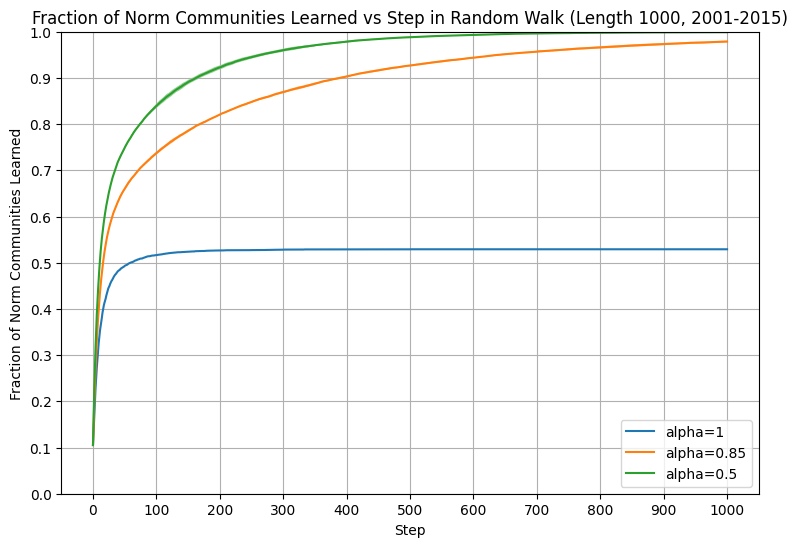

In [18]:
stats_by_alpha_1000 = {}

for alpha, curves in curves_by_alpha_1000.items():
    curves = np.array(curves)

    # Average across trials for each alpha
    mean_curve = np.mean(curves, axis=0)
    std_curve = np.std(curves, axis=0)

    stats_by_alpha_1000[alpha] = (mean_curve, std_curve)

plt.figure(figsize=(9, 6))

for alpha, (mean_curve, std_curve) in stats_by_alpha_1000.items():
    x = np.arange(len(mean_curve))

    plt.plot(x, mean_curve, label=f'alpha={alpha}')
    plt.fill_between(
        x,
        mean_curve - std_curve,
        mean_curve + std_curve,
        alpha=0.5
    )

plt.xlabel("Step")
plt.ylabel("Fraction of Norm Communities Learned")
plt.ylim(0, 1)
plt.yticks(np.arange(0, 1.1, 0.1))
plt.xticks(np.arange(0, 1001, 100))
plt.title("Fraction of Norm Communities Learned vs Step in Random Walk (Length 1000, 2001-2015)")
plt.legend()
plt.grid(True)

plt.show()

**KEY OBSERVATIONS**

*   The maximum fraction of learned norms converges within 100 steps for alpha=1, ~700 for alpha=1, and appears to take more than 1000 steps for alpha=0.85
* The variance of each learned norm fraction is very low across random seeds (almost none)
*   For shorter walks, all three alphas appear to learn the same fraction of norms, but this number quickly separates at 100 steps. However, alpha=0.85 catches back up to alpha=0.5
*   Walk length = 10
    * Minimum fraction rises from 0/9 to 1/9-2/9 as alpha decreases.
    * Maximum fraction rises from 6/9 to 7/9-8/9 as alpha decreases.
*   Walk length = 100
    * Minimum fraction rises from 0/9 to 5/9 going from deterministic to probabilistic
    * Maximum fraction rises from 8/9 to 9/9 going from deterministic to probabilistic
    * Fraction of learned norms is similiar in alpha=0.85 and alpha=0.5 cases, but we also see that the shortest hitting time increases while the longest hitting time decreases.
*   Walk length = 1000
    * All alphas end up learning a maximum fraction of 9/9 norms
    * alpha=1 has a minimum fraction of 0, while the others learn 7/9 and 8/9 respectively.
    * Hitting time for shortest nodes is longer for alpha=0.5 than alpha=0.85
    * Hitting time for longest nodes is shorter for alpha=0.5 than alpha=0.85


* For the longer walks, we see the same norms appear as the shortest hitting times, indicating that norms like "('Neutral_point_of_view', 'Article Quality') and "('What_Wikipedia_is_not', 'Article Quality')" are most important
* The longest hitting times vary greatly in types of articles, indicating that longer hitting times are less important nodes
* Deterministic walks have common shortest hitting time nodes across random seeds


#### 2001-2007

In [19]:
curves_by_alpha_10 = defaultdict(list)

walk_length = 10
for alpha in [1, 0.85, 0.5]:
    for random_trial in np.arange(5):
        print(f"Trial {random_trial}: Walk Length = {walk_length}, Alpha = {alpha}")
        seed = 42 + 100 * random_trial
        np.random.seed(seed)

        walks = random_walk(G_2007, num_walks=1000, walk_length=walk_length, alpha=alpha)

        hitting_times = sorted(compute_hitting_times(walks).items(), key=lambda x:x[1])
        fastest_5 = hitting_times[:5]
        slowest_5 = hitting_times[-5:]

        fractions, avg_fraction = fraction_of_learned_communities(walks)
        max_fraction = max(fractions)
        min_fraction = min(fractions)

        fraction_per_step = average_learning_curve(walks)
        curves_by_alpha_10[alpha].append(fraction_per_step)

        print("Fastest 5 hitting times:", fastest_5)
        print("Slowest 5 hitting times:", slowest_5)
        print("Maximum fraction of learned norms in a walk:", max_fraction)
        print("Minimum fraction of learned norms in a walk:", min_fraction)
        print()
    print("____________________________________________________________")

Trial 0: Walk Length = 10, Alpha = 1
Fastest 5 hitting times: [(('Pools', 'Content Policies'), np.float64(0.0)), (('Category_types', 'None'), np.float64(0.0)), (('Wikipedia_cited_on_usenet', 'Administrators'), np.float64(0.0)), (('Categories_versus_lists', 'Formatting Articles'), np.float64(0.0)), (('Notability_sub-pages', 'Article Quality'), np.float64(0.0))]
Slowest 5 hitting times: [(('Wikipediholism_test', 'Wiki-larping'), np.float64(10.0)), (('News_articles', 'Article Quality'), np.float64(10.0)), (('Pro_and_con_lists', 'Article Quality'), np.float64(10.0)), (('Naming_conventions_(languages)', 'Formatting Articles'), np.float64(10.0)), (('Risk_disclaimer', 'Content Policies'), np.float64(10.0))]
Maximum fraction of learned norms in a walk: 0.6666666666666666
Minimum fraction of learned norms in a walk: 0.0

Trial 1: Walk Length = 10, Alpha = 1
Fastest 5 hitting times: [(('Pools', 'Content Policies'), np.float64(0.0)), (('Category_types', 'None'), np.float64(0.0)), (('Wikipedia_cit

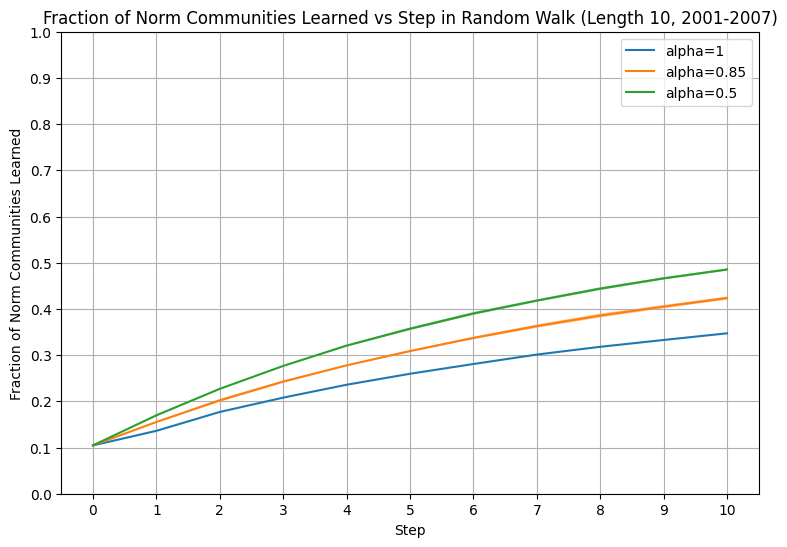

In [20]:
stats_by_alpha_10 = {}

for alpha, curves in curves_by_alpha_10.items():
    curves = np.array(curves)

    # Average across trials for each alpha
    mean_curve = np.mean(curves, axis=0)
    std_curve = np.std(curves, axis=0)

    stats_by_alpha_10[alpha] = (mean_curve, std_curve)

plt.figure(figsize=(9, 6))

for alpha, (mean_curve, std_curve) in stats_by_alpha_10.items():
    x = np.arange(len(mean_curve))

    plt.plot(x, mean_curve, label=f'alpha={alpha}')
    plt.fill_between(
        x,
        mean_curve - std_curve,
        mean_curve + std_curve,
        alpha=0.5
    )

plt.xlabel("Step")
plt.ylabel("Fraction of Norm Communities Learned")
plt.title("Fraction of Norm Communities Learned vs Step in Random Walk (Length 10, 2001-2007)")
plt.ylim(0, 1)
plt.yticks(np.arange(0, 1.1, 0.1))
plt.xticks(np.arange(0, 11, 1))
plt.legend()
plt.grid(True)

plt.show()

In [21]:
curves_by_alpha_100 = defaultdict(list)

walk_length = 100
for alpha in [1, 0.85, 0.5]:
    for random_trial in np.arange(5):
        print(f"Trial {random_trial}: Walk Length = {walk_length}, Alpha = {alpha}")
        seed = 42 + 100 * random_trial
        np.random.seed(seed)

        walks = random_walk(G_2007, num_walks=1000, walk_length=walk_length, alpha=alpha)

        hitting_times = sorted(compute_hitting_times(walks).items(), key=lambda x:x[1])
        fastest_5 = hitting_times[:5]
        slowest_5 = hitting_times[-5:]

        fractions, avg_fraction = fraction_of_learned_communities(walks)
        max_fraction = max(fractions)
        min_fraction = min(fractions)

        fraction_per_step = average_learning_curve(walks)
        curves_by_alpha_100[alpha].append(fraction_per_step)

        print("Fastest 5 hitting times:", fastest_5)
        print("Slowest 5 hitting times:", slowest_5)
        print("Maximum fraction of learned norms in a walk:", max_fraction)
        print("Minimum fraction of learned norms in a walk:", min_fraction)
        print()
    print("____________________________________________________________")

Trial 0: Walk Length = 100, Alpha = 1
Fastest 5 hitting times: [(('Embrace_weasel_words', 'Article Quality'), np.float64(0.0)), (('Mark_of_Cain', 'Collaboration'), np.float64(0.0)), (('Wikipedia_may_or_may_not_be_failing', 'Content Policies'), np.float64(0.0)), (('Wikiness', 'Collaboration'), np.float64(0.0)), (('Sociology_of_Wikipedia_via_Rorty_and_Berger', 'None'), np.float64(0.0))]
Slowest 5 hitting times: [(('Avoid_using_meta-templates', 'Formatting Articles'), np.float64(62.0)), (('Steamroll_minority_opinions', 'Collaboration'), np.float64(69.5)), (('Notability_(media)', 'Article Quality'), np.float64(74.0)), (("Don't_hope_the_house_will_build_itself", 'Article Quality'), np.float64(81.0)), (('Not_every_page_needs_a_tag', 'Collaboration'), np.float64(88.0))]
Maximum fraction of learned norms in a walk: 1.0
Minimum fraction of learned norms in a walk: 0.0

Trial 1: Walk Length = 100, Alpha = 1
Fastest 5 hitting times: [(('Embrace_weasel_words', 'Article Quality'), np.float64(0.0)),

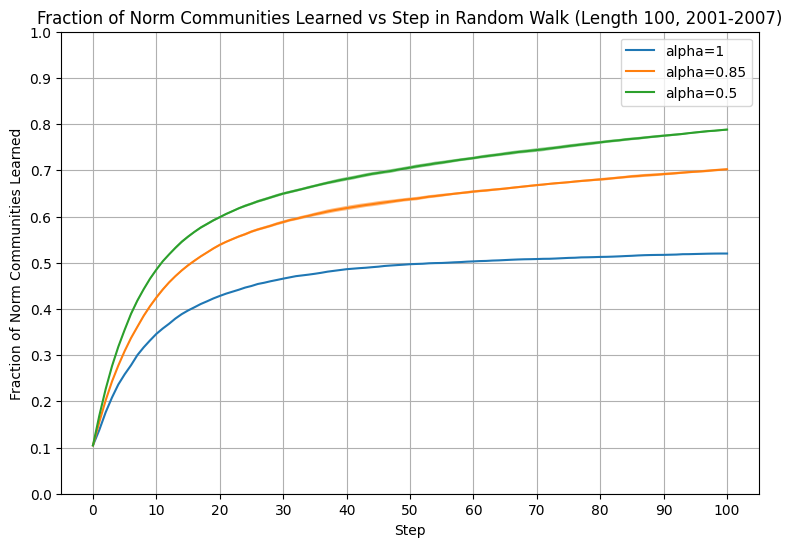

In [22]:
stats_by_alpha_100 = {}

for alpha, curves in curves_by_alpha_100.items():
    curves = np.array(curves)

    # Average across trials for each alpha
    mean_curve = np.mean(curves, axis=0)
    std_curve = np.std(curves, axis=0)

    stats_by_alpha_100[alpha] = (mean_curve, std_curve)

plt.figure(figsize=(9, 6))

for alpha, (mean_curve, std_curve) in stats_by_alpha_100.items():
    x = np.arange(len(mean_curve))

    plt.plot(x, mean_curve, label=f'alpha={alpha}')
    plt.fill_between(
        x,
        mean_curve - std_curve,
        mean_curve + std_curve,
        alpha=0.5
    )

plt.xlabel("Step")
plt.ylabel("Fraction of Norm Communities Learned")
plt.ylim(0, 1)
plt.yticks(np.arange(0, 1.1, 0.1))
plt.xticks(np.arange(0, 101, 10))
plt.title("Fraction of Norm Communities Learned vs Step in Random Walk (Length 100, 2001-2007)")
plt.legend()
plt.grid(True)

plt.show()

In [23]:
curves_by_alpha_1000 = defaultdict(list)

walk_length = 1000
for alpha in [1, 0.85, 0.5]:
    for random_trial in np.arange(5):
        print(f"Trial {random_trial}: Walk Length = {walk_length}, Alpha = {alpha}")
        seed = 42 + 100 * random_trial
        np.random.seed(seed)

        walks = random_walk(G_2007, num_walks=1000, walk_length=walk_length, alpha=alpha)

        hitting_times = sorted(compute_hitting_times(walks).items(), key=lambda x:x[1])
        fastest_5 = hitting_times[:5]
        slowest_5 = hitting_times[-5:]

        fractions, avg_fraction = fraction_of_learned_communities(walks)
        max_fraction = max(fractions)
        min_fraction = min(fractions)

        fraction_per_step = average_learning_curve(walks)
        curves_by_alpha_1000[alpha].append(fraction_per_step)

        print("Fastest 5 hitting times:", fastest_5)
        print("Slowest 5 hitting times:", slowest_5)
        print("Maximum fraction of learned norms in a walk:", max_fraction)
        print("Minimum fraction of learned norms in a walk:", min_fraction)
        print()
    print("____________________________________________________________")

Trial 0: Walk Length = 1000, Alpha = 1
Fastest 5 hitting times: [(('Comparison_to_Stanford_Encyclopedia_of_Philosophy', 'Content Policies'), np.float64(0.0)), (('Differences_between_the_English_Wikipedia_and_Wikipedias_in_other_languages', 'Content Policies'), np.float64(0.0)), (('Naming_conventions_(U.S._schools)', 'Formatting Articles'), np.float64(0.0)), (('Naming_conventions_(Seasons)', 'Formatting Articles'), np.float64(0.0)), (('Trial_adminship', 'None'), np.float64(0.0))]
Slowest 5 hitting times: [(('Testimonials', 'Content Policies'), np.float64(252.0)), (('Criticisms', 'Content Policies'), np.float64(298.5)), (("Don't_edit_for_power", 'Administrators'), np.float64(502.0)), (("Avoid_Parkinson's_Bicycle_Shed_Effect", 'Collaboration'), np.float64(536.0)), (('Talk_page_highlights', 'Administrators'), np.float64(598.0))]
Maximum fraction of learned norms in a walk: 1.0
Minimum fraction of learned norms in a walk: 0.0

Trial 1: Walk Length = 1000, Alpha = 1
Fastest 5 hitting times: 

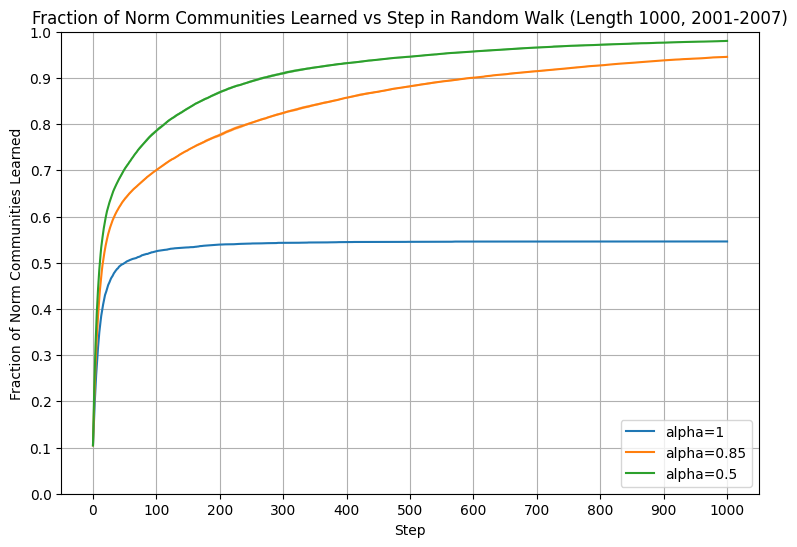

In [24]:
stats_by_alpha_1000 = {}

for alpha, curves in curves_by_alpha_1000.items():
    curves = np.array(curves)

    # Average across trials for each alpha
    mean_curve = np.mean(curves, axis=0)
    std_curve = np.std(curves, axis=0)

    stats_by_alpha_1000[alpha] = (mean_curve, std_curve)

plt.figure(figsize=(9, 6))

for alpha, (mean_curve, std_curve) in stats_by_alpha_1000.items():
    x = np.arange(len(mean_curve))

    plt.plot(x, mean_curve, label=f'alpha={alpha}')
    plt.fill_between(
        x,
        mean_curve - std_curve,
        mean_curve + std_curve,
        alpha=0.5
    )

plt.xlabel("Step")
plt.ylabel("Fraction of Norm Communities Learned")
plt.ylim(0, 1)
plt.yticks(np.arange(0, 1.1, 0.1))
plt.xticks(np.arange(0, 1001, 100))
plt.title("Fraction of Norm Communities Learned vs Step in Random Walk (Length 1000, 2001-2007)")
plt.legend()
plt.grid(True)

plt.show()